In [77]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [78]:
# load  all the cleaned  dats sets

fund = pd.read_csv("../data/processed/clean_fund_master.csv")

nav = pd.read_csv("../data/processed/clean_nav.csv")

fact_transactions = pd.read_csv("../data/processed/clean_transactions.csv")

performance = pd.read_csv("../data/processed/clean_performance.csv")

fund_house = pd.read_csv("../data/processed/clean_aum_by_fund_house.csv")

monthly_sip = pd.read_csv("../data/processed/clean_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/clean_category_inflows.csv")

folio = pd.read_csv("../data/processed/clean_industry_folio_count.csv")

portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/processed/clean_benchmark_indices.csv")

In [79]:
# Convert date columns

nav["date"] = pd.to_datetime(nav["date"])

fact_transactions["transaction_date"] = pd.to_datetime(
    fact_transactions["transaction_date"]
)

fund_house["date"] = pd.to_datetime(fund_house["date"])

monthly_sip["month"] = pd.to_datetime(monthly_sip["month"])

folio["month"] = pd.to_datetime(folio["month"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [28]:
# Check all datasets

datasets = {
    "Fund": fund,
    "NAV": nav,
    "Transactions": fact_transactions,
    "Performance": performance,
    "AUM": fund_house,
    "SIP": monthly_sip,
    "Category": category,
    "Folio": folio,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print("="*60)
    print(name)
    print(df.shape)
    print(df.head())

Fund
(40, 15)
   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lum

In [80]:
# Merge scheme names.

nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)
nav.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-1.030568,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,1.286515,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-1.137747,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.120999,HDFC Top 100 Fund - Regular Plan - Growth


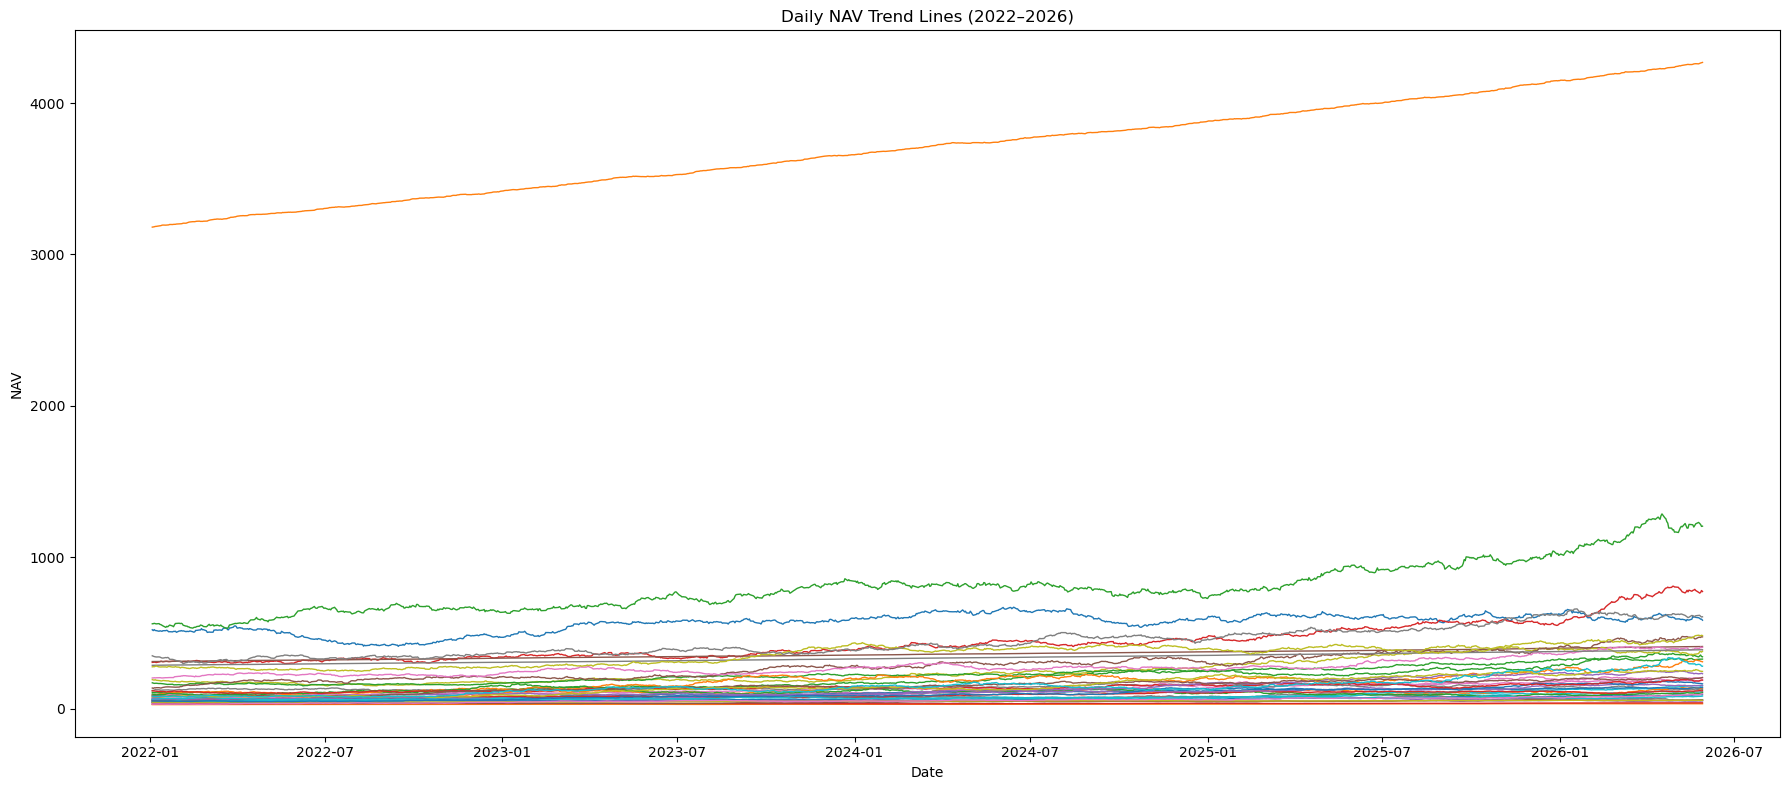

In [81]:
# 1. nav trend lines chart

# Create the chart.

plt.figure(figsize=(18,8))

for scheme in nav["scheme_name"].unique():
    temp = nav[nav["scheme_name"] == scheme]
    plt.plot(
        temp["date"],
        temp["nav"],
        linewidth=1
    )

plt.title("Daily NAV Trend Lines (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.tight_layout()

# Save the daily nav trend lines chart
plt.savefig(
    "../reports/query_results/charts/nav_trend_lines.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [84]:
monthly_sip[["month","active_sip_accounts_crore","yoy_growth_pct"]].tail(15)

,month,active_sip_accounts_crore,yoy_growth_pct
33,2024-10-01,8.30,49.59
34,2024-11-01,8.40,48.30
35,2024-12-01,8.50,50.25
36,2025-01-01,8.22,40.14
37,2025-02-01,8.30,35.50
38,2025-03-01,8.11,27.27
39,2025-04-01,8.38,30.73
40,2025-05-01,8.50,25.52
41,2025-06-01,8.62,28.28
42,2025-07-01,8.75,22.00


In [85]:
# 2. AUM Growth by Fund House

fund_house.info()  # info() gives columns with data types

fund_house.head()  # head() gives the columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[ns]
 1   fund_house      90 non-null     object        
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 3.6+ KB


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [86]:
# Convert the date

fund_house["date"] = pd.to_datetime(fund_house["date"])

fund_house["year"] = fund_house["date"].dt.year

# Keep only year 2022–2025
aum = fund_house[
    fund_house["year"].between(2022, 2025)
]

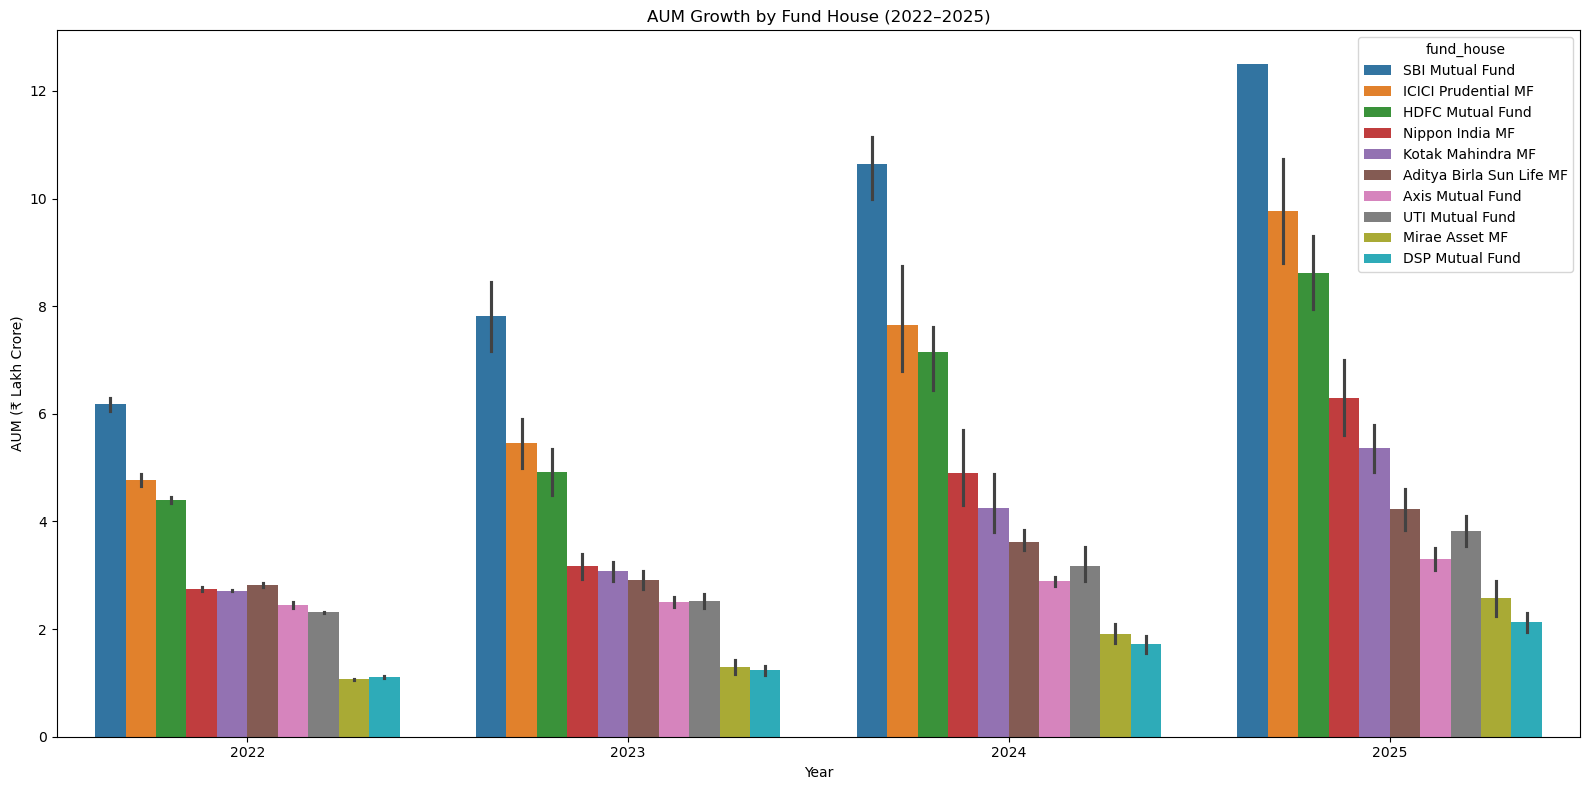

In [87]:
# # 2. AUM Growth by AMC  by Boxplot chart

# Create the chart

plt.figure(figsize=(16,8))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=0)

plt.tight_layout()

# save the  aum_growth_by_fund_house image
plt.savefig(
    "../reports/query_results/charts/aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [88]:
# 3. SIP Inflow Time-Series

# Check the data

monthly_sip.info()
monthly_sip.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[ns]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             48 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 2.4 KB


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,0.0
1,2022-02-01,11438,4.93,8.20,4.85,0.0
2,2022-03-01,12328,5.09,10.50,5.01,0.0
3,2022-04-01,11863,5.48,9.52,5.12,0.0
4,2022-05-01,12286,5.55,8.10,5.15,0.0


In [89]:
# Convert month to datetime

monthly_sip["month"] = pd.to_datetime(monthly_sip["month"])

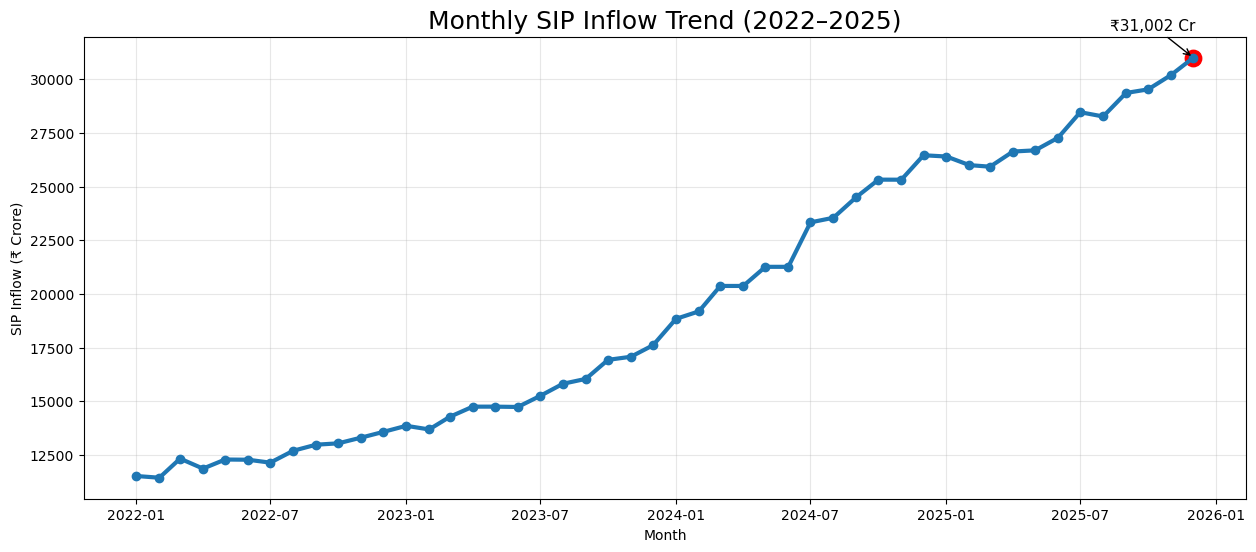

In [91]:
# 3. SIP Inflow Trend  by  plot chart

# create the chart

plt.figure(figsize=(15,6))

plt.plot(
    monthly_sip["month"],
    monthly_sip["sip_inflow_crore"],
    linewidth=3,
    marker="o"
)

plt.title("Monthly SIP Inflow Trend (2022–2025)", fontsize=18)

plt.xlabel("Month")

plt.ylabel("SIP Inflow (₹ Crore)")

plt.grid(alpha=0.3)


# Highlight the December 2025 milestone
last = monthly_sip.iloc[-1]

plt.scatter(
    last["month"],
    last["sip_inflow_crore"],
    color="red",
    s=140
)

plt.annotate(
    "₹31,002 Cr",
    xy=(last["month"], last["sip_inflow_crore"]),
    xytext=(-60,20),
    textcoords="offset points",
    fontsize=11,
    arrowprops=dict(arrowstyle="->")
)

# save the sip flow chart
plt.savefig(
    "../reports/query_results/charts/sip_inflow_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
# 4.category_heatmap

# Check the data
category.head()

category.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             144 non-null    object
 1   category          144 non-null    object
 2   net_inflow_crore  144 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 3.5+ KB


In [93]:
# Convert month to datetime

category["month"] = pd.to_datetime(category["month"], errors="coerce")

In [94]:
# Convert month into Month-Year format

category["month_name"] = category["month"].dt.strftime("%b-%Y")

In [95]:
# Create the pivot table

heatmap_data = category.pivot(
    index="category",
    columns="month_name",
    values="net_inflow_crore"
)
heatmap_data.head()

month_name,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466,499,521,437,516,471,472,500,553,571,537,537
Flexi Cap,4947,5562,4654,6068,5603,4869,4478,4767,5529,6111,6004,5397
Gilt,784,952,831,942,744,959,864,956,836,704,898,925
Hybrid,2955,3684,3538,3360,2967,3291,3163,2830,3487,3264,3314,3015
Large & Mid Cap,4214,5411,4878,5524,4816,5023,4610,4243,4368,5556,4581,4528


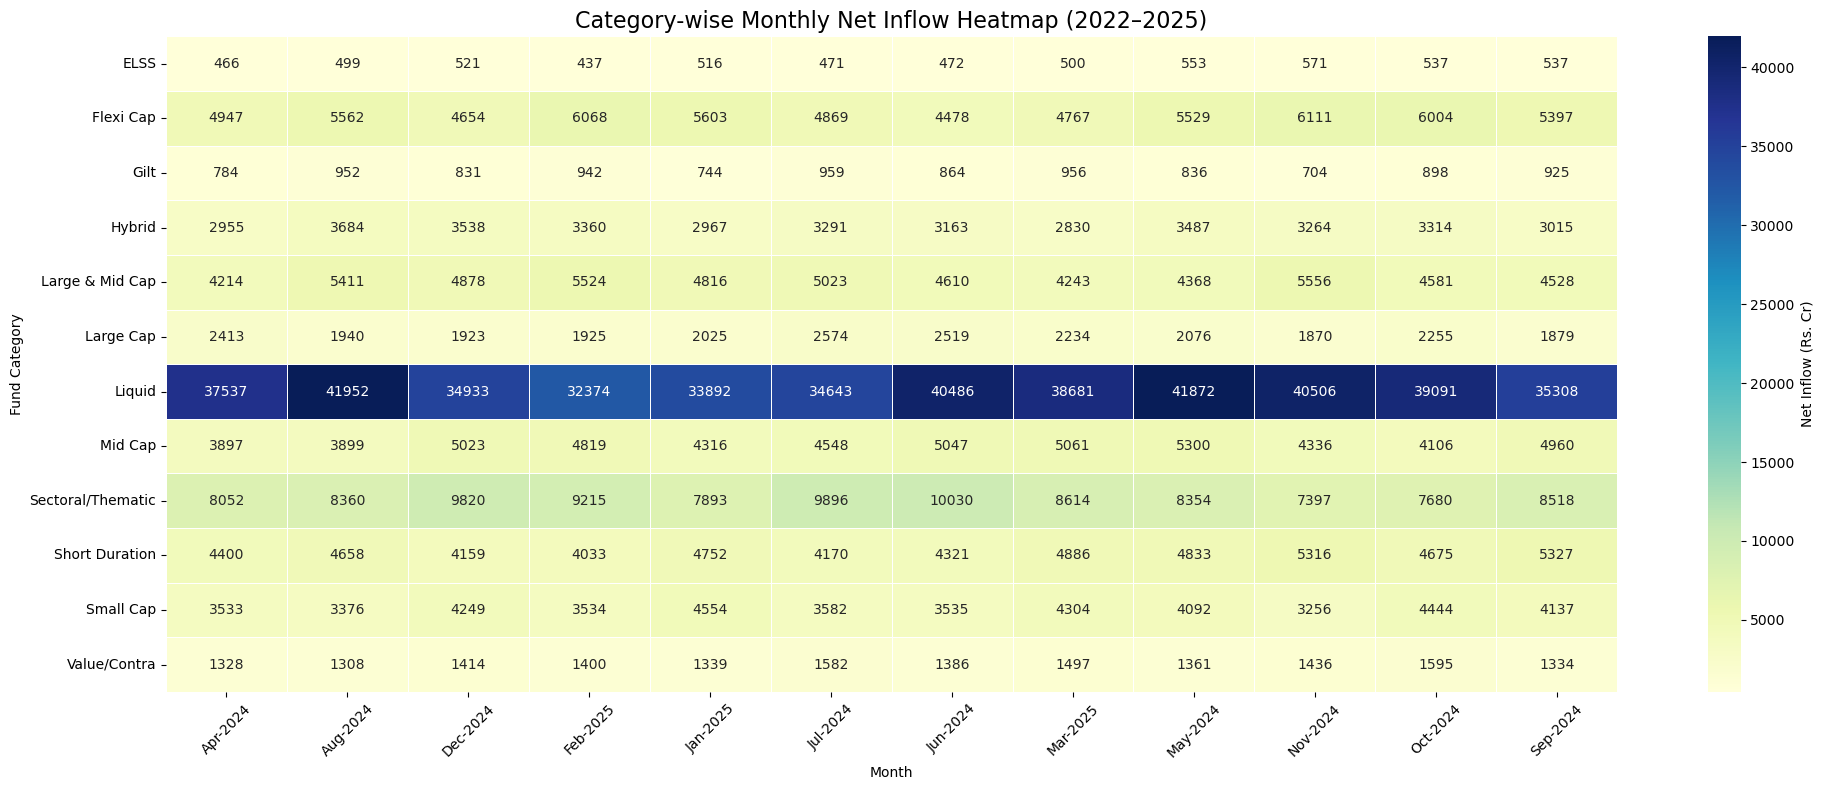

In [96]:
# 4. Category Heatmap chart

# create or plot  the heatmap
plt.figure(figsize=(20, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={'label':'Net Inflow (Rs. Cr)'}
)

plt.title("Category-wise Monthly Net Inflow Heatmap (2022–2025)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

# Save the chart
plt.savefig(
    "../reports/query_results/charts/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [97]:
# chart 5: Investor Demographics

# Chart 5A: Age Group Distribution (Pie Chart)

# Check your transactions data columns:
fact_transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [98]:
# Create age group counts

age_dist = fact_transactions["age_group"].value_counts()

age_dist

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

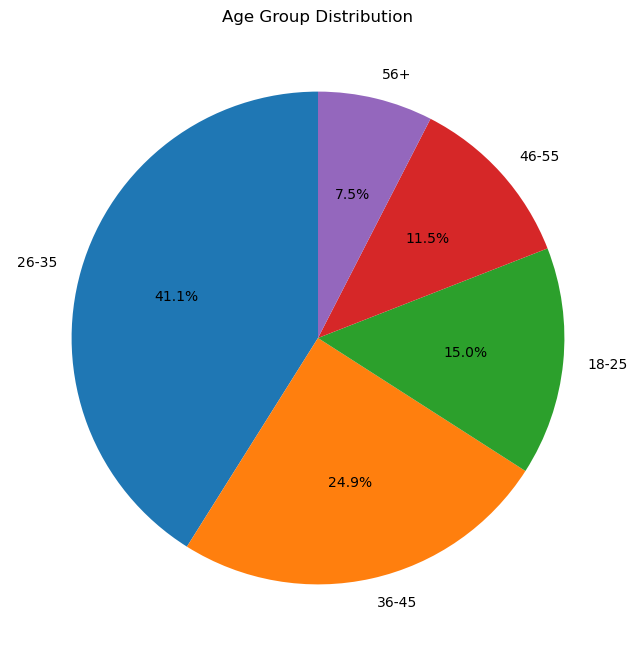

In [99]:
#  5A: Age Group Distribution  by Pie Chart

# Create Pie Chart
plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Age Group Distribution")
plt.savefig(
    "../reports/query_results/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
# Filter SIP transactions

plt.show()


In [100]:
# Chart 5B: SIP Amount by Age Group (Box Plot)

# Filter SIP transactions

monthly_sip = fact_transactions[
    fact_transactions["transaction_type"] == "SIP"
]

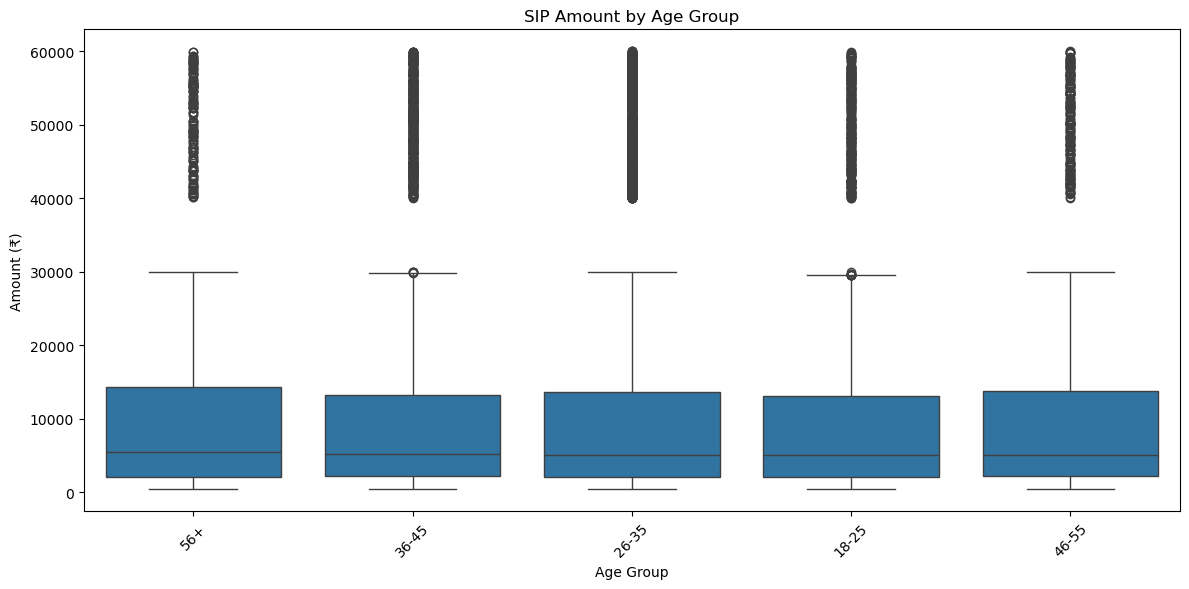

In [101]:
# 5B: SIP Amount by Age Group by Box Plot

# Create Box Plot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=monthly_sip,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")  

plt.xlabel("Age Group")

plt.ylabel("Amount (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

# save the chart
plt.savefig(
    "../reports/query_results/charts/sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [102]:
# Task 6: Geographic Distribution.

#  State-wise SIP Amount (Horizontal Bar Chart)

# Step 1: Aggregate SIP Amount by State
state_sip = (
    fact_transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip.head()

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
Name: amount_inr, dtype: int64

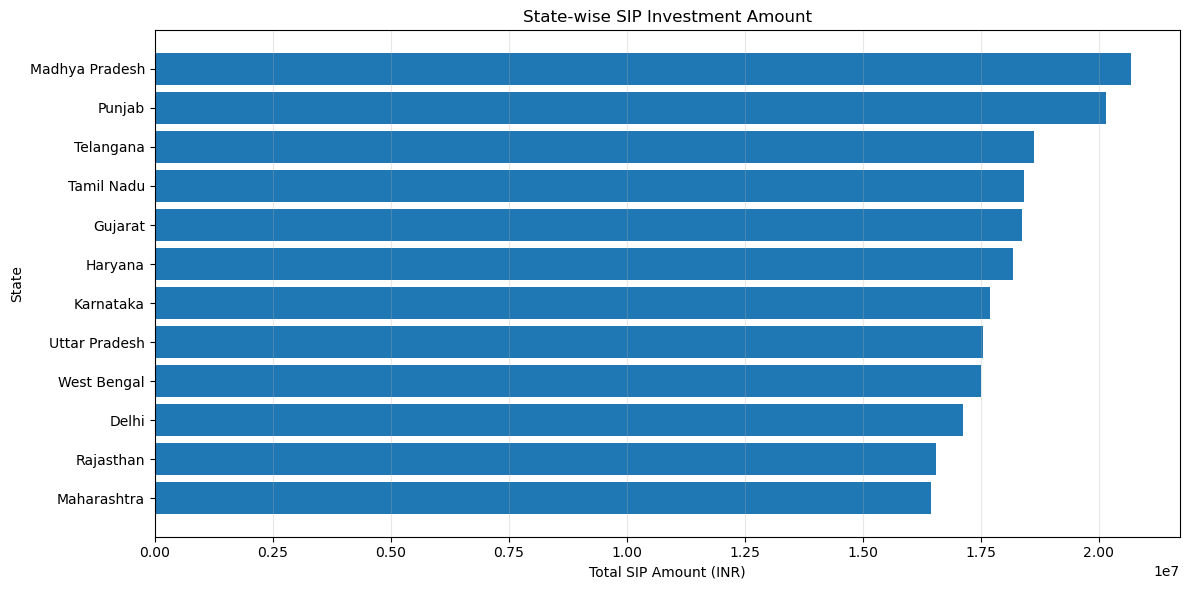

In [103]:
# chart 6A: Geographic distribution: Horizontal bar chart

# chart 7 Horizontal bar chart
# Step 2: Plot Horizontal Bar Chart

# Load data
fact_transactions = pd.read_csv("../data/processed/clean_transactions.csv")

# Filter only SIP transactions
sip = fact_transactions[
    fact_transactions["transaction_type"] == "SIP"
]

# Total SIP amount by state
state_sip = (
    sip.groupby("state")["amount_inr"]
       .sum()
       .sort_values()
)

# Plot
plt.figure(figsize=(12,6))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title("State-wise SIP Investment Amount")  

plt.xlabel("Total SIP Amount (INR)")

plt.ylabel("State")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/query_results/charts/state_wise_sip_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [106]:
# chart 6B:  SIP amount by state. T30 vs B30 pie chart

# Step 1: Check Available Values
fact_transactions["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

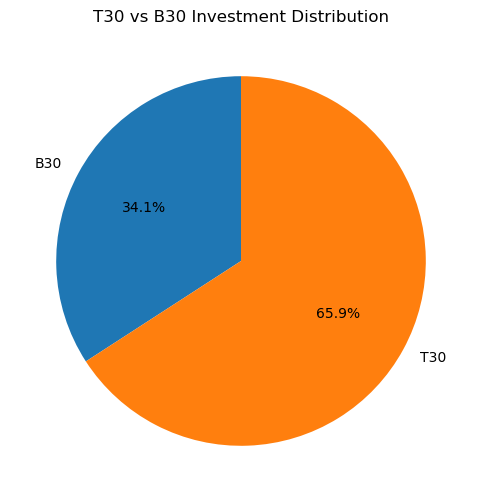

In [107]:
# Chart 8: T30 vs B30 Distribution

# Step 2: Create Pie Chart

tier = (
    fact_transactions
    .groupby("city_tier")["amount_inr"]
    .sum()
)
plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investment Distribution")

plt.savefig(
   "../reports/query_results/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
# Task 7: Folio Count Growth (Chart 9)
# Step 1: Check the folio dataset

folio.columns.tolist()

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


In [60]:
#folio["month"] = pd.to_datetime(folio["month"])

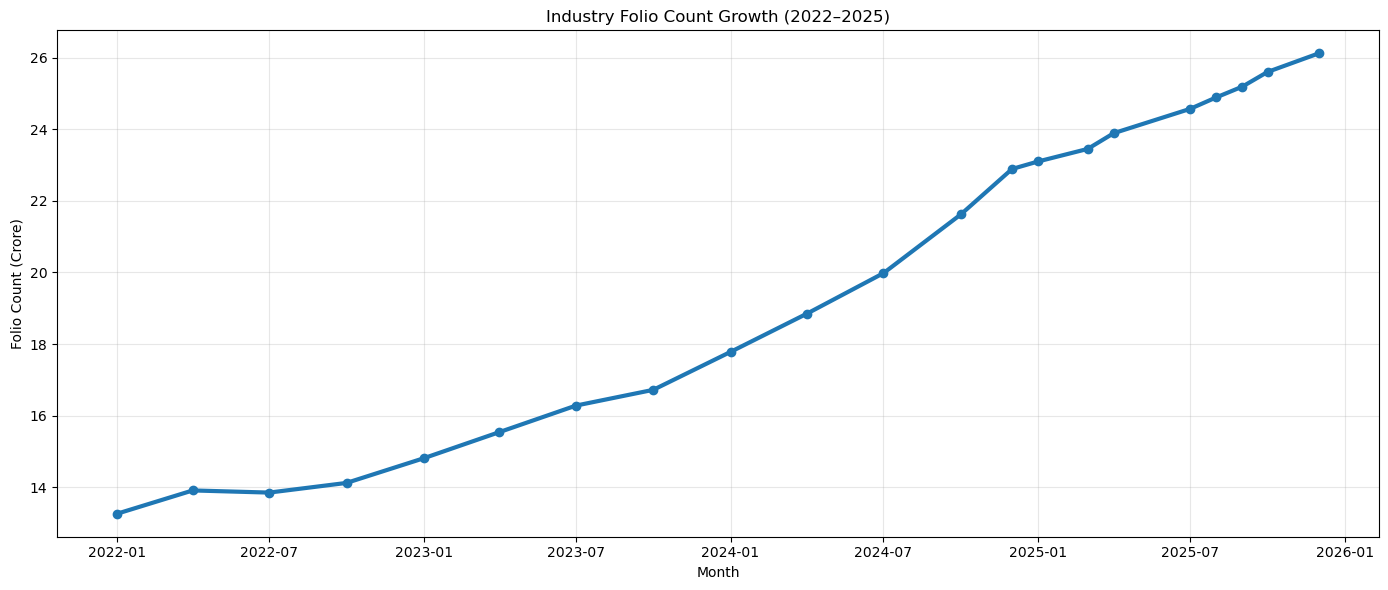

In [109]:
# Chart 9: Industry Folio Count Growth 

# Step 3: Create Line Chart
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=3,
    marker="o"
)

plt.title("Industry Folio Count Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Folio Count (Crore)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../reports/query_results/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [110]:
# Task 8: Correlation Matrix
# Step 1: Create Return Matrix
returns = nav.pivot_table(
    index="date",
    columns="scheme_name",
    values="daily_return"
)

In [111]:
# Step 2: Select Top 10 Funds
top10 = returns.columns[:10]

returns= returns[top10]

In [112]:
# Step 3: Correlation Matrix
corr_matrix = returns.corr()

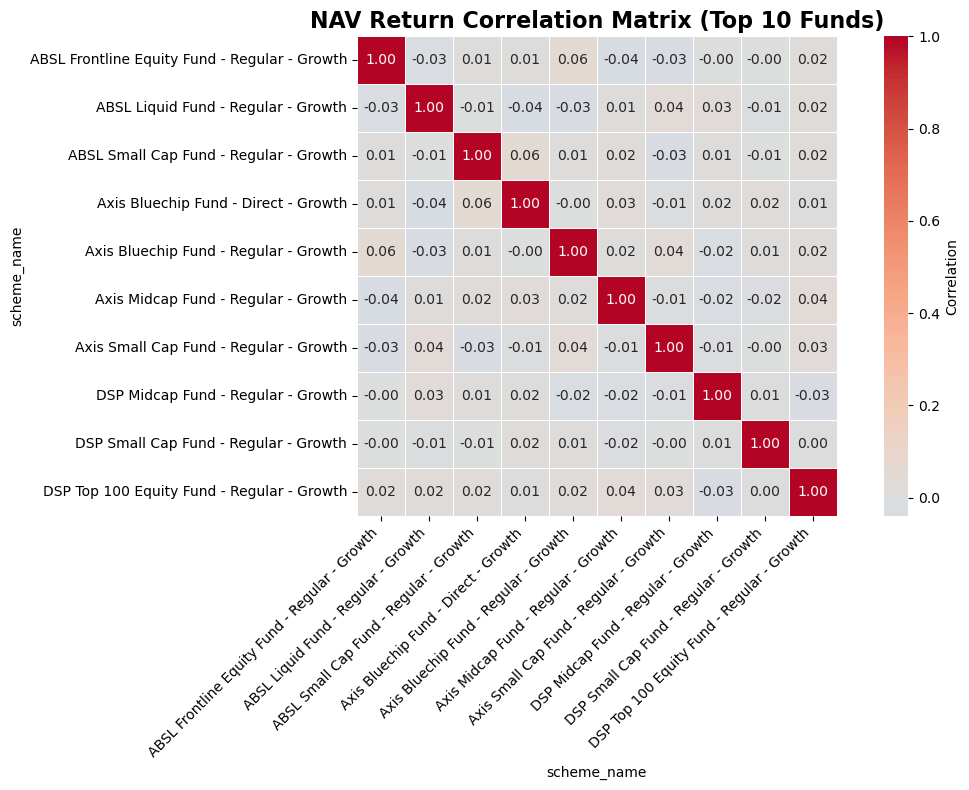

In [69]:
# Chart 10: NAV Return Correlation Matrix

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)

plt.title(
    "NAV Return Correlation Matrix (Top 10 Funds)",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# Save chart
plt.savefig(
    "../reports/query_results/charts/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
# Task 9: Top Holdings Sector Distribution (Chart 11)
# Step 1: Check the portfolio dataset
portfolio.head()

portfolio.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [71]:
# Step 1: Group sector weights
sector_weights = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

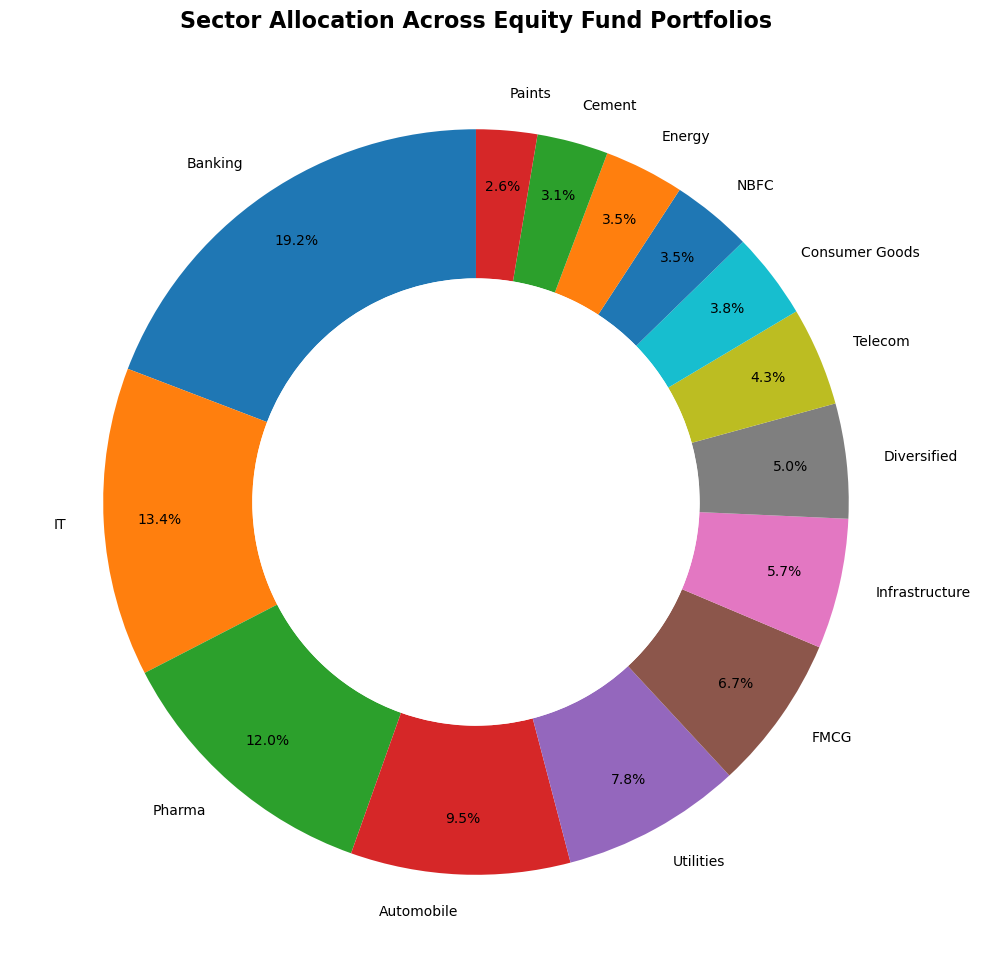

In [72]:
# Chart 11:  Top holdings sector distribution donut chart

# Step 2: Create the Donut Chart

plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4},
    pctdistance=0.85
)

# Draw white circle in the center
centre_circle = plt.Circle((0,0),0.60,fc="white")
plt.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Equity Fund Portfolios",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

# save the chart
plt.savefig(
    "../reports/query_results/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
# Task 10: Final Charts + EDA Findings

top10 = (
    performance
    .sort_values("aum_crore", ascending=False)
    .head(10)
)

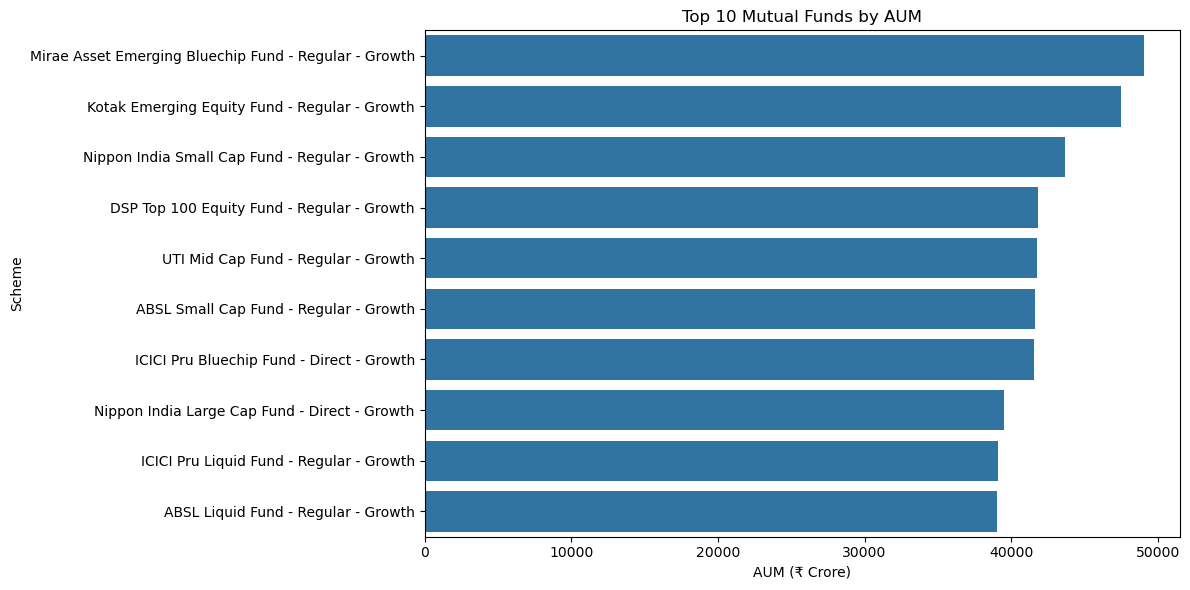

In [76]:
 # Chart 12: Top 10 Funds by AUM barplot

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by AUM")
plt.xlabel("AUM (₹ Crore)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/query_results/charts/top10_aum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

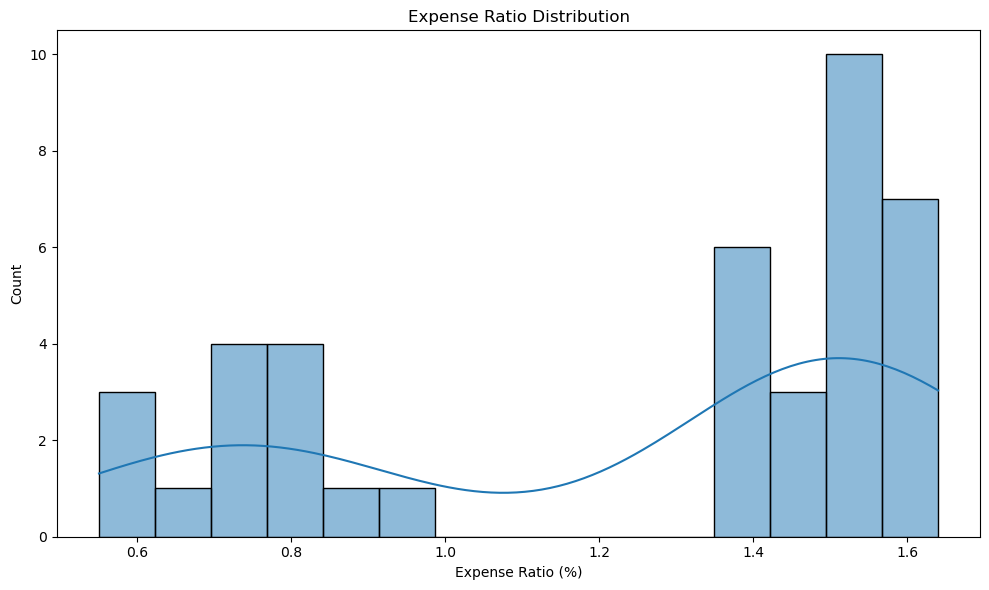

In [114]:
# Chart 13: Expense Ratio Distribution

plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio (%)")

plt.tight_layout()

# save the chart
plt.savefig(
    "../reports/query_results/charts/expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

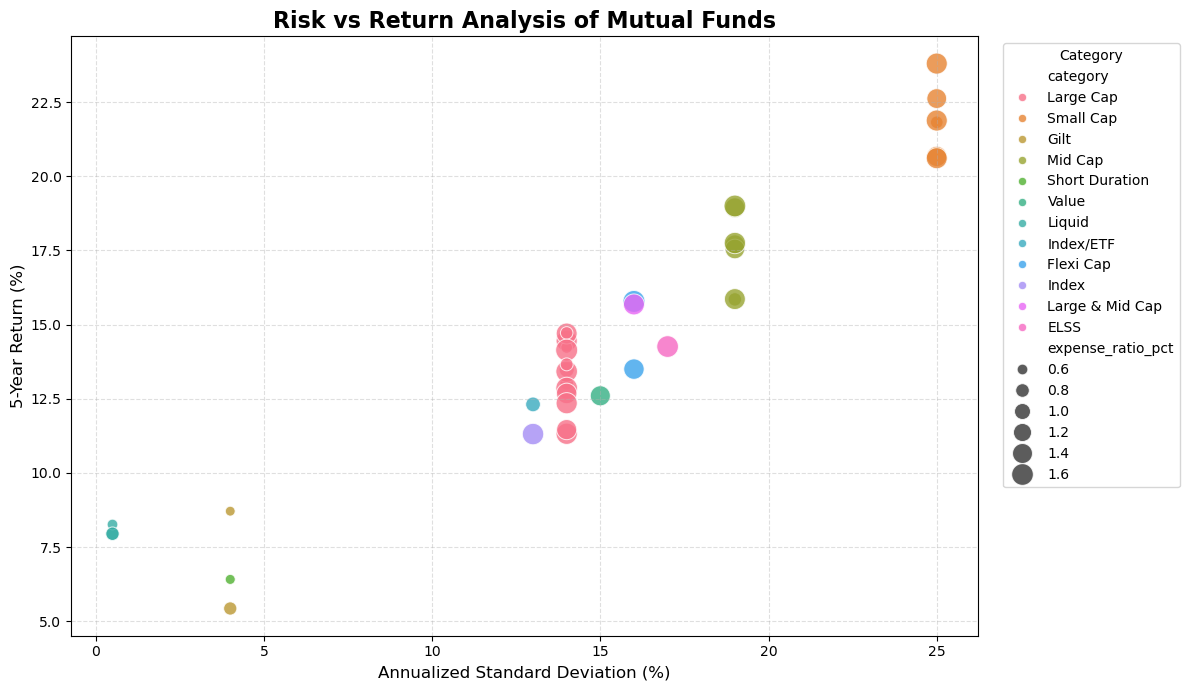

In [73]:
# Chart 14: Risk vs Return Scatter Plot

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_5yr_pct",
    hue="category",
    size="expense_ratio_pct",     # Bubble size based on expense ratio
    sizes=(50, 250),
    alpha=0.8
)

plt.title(
    "Risk vs Return Analysis of Mutual Funds",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Annualized Standard Deviation (%)",
    fontsize=12
)

plt.ylabel(
    "5-Year Return (%)",
    fontsize=12
)

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(
    title="Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save the chart
plt.savefig(
    "../reports/query_results/charts/risk_vs_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [115]:
# Chart 15: Benchmark Index Trend

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [116]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


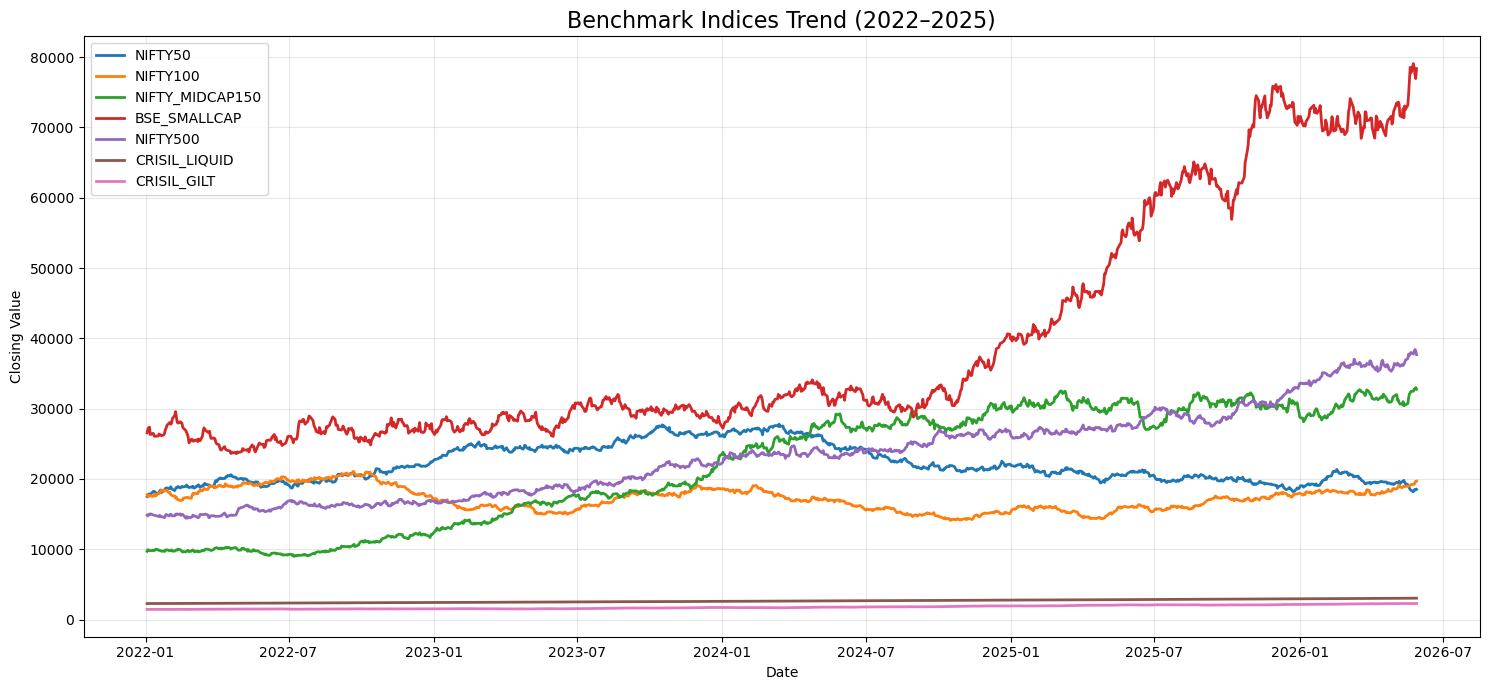

In [117]:
# Chart 15: Benchmark Index Trend

plt.figure(figsize=(15,7))

for index in benchmark["index_name"].unique():

    temp = benchmark[
        benchmark["index_name"] == index
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        linewidth=2,
        label=index
    )

plt.title("Benchmark Indices Trend (2022–2025)", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Closing Value")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

# save the chart
plt.savefig(
    "../reports/query_results/charts/benchmark_indices_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()